# PREDICTING CAR SELLING PRICES
by Ario, Anano and Judy

### Overview: 

We devided the notebook in 5 steps to have a clear & structured way:

1. Exploratory Data Analysis (EDA) 🔍
2. Data Preprocessing & Feature Engineering 🧼
3. Modeling: Multiple Regression Techniques 🧠
4. Model Comparison with Performance Metrics 📈
5. Final Model Selection & Interpretation 🏆


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For preprocessing and modeling later
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder


from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor


pd.set_option('display.float_format', lambda x: '%.2f' % x)
sns.set()

### (1) Exploratory Data Analysis (EDA) 🔍

→ Goal: understand the dataset, spot trends and potential issues.

In [57]:
# read the csv file
data = pd.read_csv('car data.csv')
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


Description of the variables: 
- Car_Name: name of the car, not relevant for the analysis later as feature
- Year: year in which the car was build
- Present_Price: current price of the car if it would be bought new
- Kms_Driven: kilometers that were driven with the car
- Fuel_Type: Fuel needed for the car
- Seller_Type: who sold the car (e.g. dealer)
- Transmission: automatic or manual transmission
- Owner: Number of owners the car had

- Selling_Price (dependent variable!): price at which the car was sold

(1.1) DATA OVERVIEW 🔍

In [58]:
# check the number of rows and columns of the data
data.shape

(301, 9)

In [59]:
# check the column types and null values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [60]:
data.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.00,301.00,301.00,301.00,301.00
mean,2013.63,4.66,7.63,36947.21,0.04
std,2.89,5.08,8.64,38886.88,0.25
min,2003.00,0.10,0.32,500.00,0.00
25%,2012.00,0.90,1.20,15000.00,0.00
50%,2014.00,3.60,6.40,32000.00,0.00
75%,2016.00,6.00,9.90,48767.00,0.00
max,2018.00,35.00,92.60,500000.00,3.00


In [61]:
# check for missing values
data.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [62]:
# check unique values in each column

print (data.nunique())
print ("")
print ("Fuel Type:", data['Fuel_Type'].unique())
print ("Seller Type:", data['Seller_Type'].unique())
print ("Transmission:", data['Transmission'].unique())
print ("Owner Type:", data['Owner'].unique())

Car_Name          98
Year              16
Selling_Price    156
Present_Price    147
Kms_Driven       206
Fuel_Type          3
Seller_Type        2
Transmission       2
Owner              3
dtype: int64

Fuel Type: ['Petrol' 'Diesel' 'CNG']
Seller Type: ['Dealer' 'Individual']
Transmission: ['Manual' 'Automatic']
Owner Type: [0 1 3]


In [63]:
#drop unnessary columns: we do not need the Car_Name column for our analysis
data.drop(['Car_Name'], axis=1, inplace=True)

In [64]:
# add care age column
data['Car_Age'] = 2025 - data['Year']
data.drop(['Year'], axis=1, inplace=True)

(1.2) TARGET VARIABLE DESTRIBUTION 🔍

In [65]:
# destribution of the target variable
data['Selling_Price'].describe()

count   301.00
mean      4.66
std       5.08
min       0.10
25%       0.90
50%       3.60
75%       6.00
max      35.00
Name: Selling_Price, dtype: float64

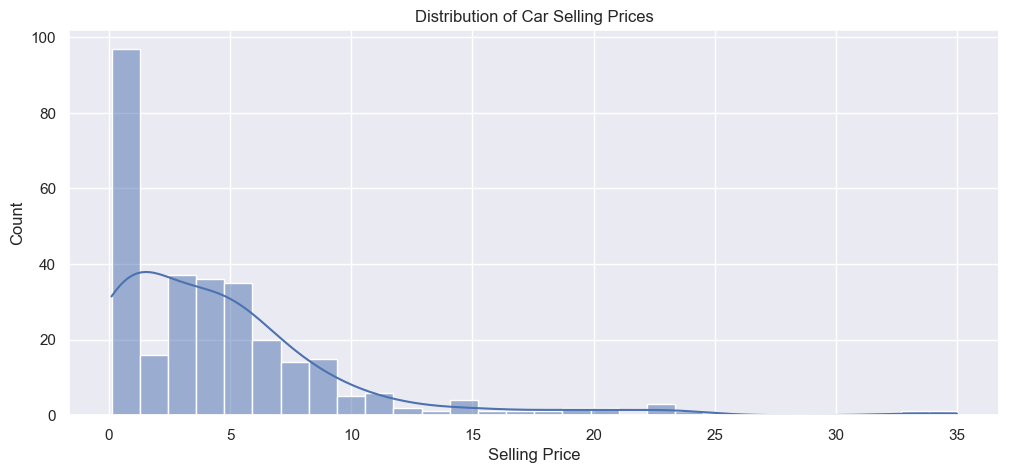

In [66]:
# check the distribution and skewness of the target variable
plt.figure(figsize=(12, 5))
sns.histplot(data['Selling_Price'], bins=30, kde=True)
plt.title('Distribution of Car Selling Prices')
plt.xlabel('Selling Price')
plt.show()

👉 The destribution is right-skewed , which most cars being sold for less than 10 units and there are a few high-price outliers, going up to ~35 untis The mean is pulled toward the high-price outliers and the model might perform poorly on lower-priced cars. There is a spike right at 0  or near 0, poissibly representing freee transfers, invalid entries or unusually cheap cars.

This can have an impact later with linear models, as linear models assume the target variable is normally distributed and the skewness therfore might affect model performance. Log Transformation might help!


(1.3)  FEATURE CORRELATION 🔍

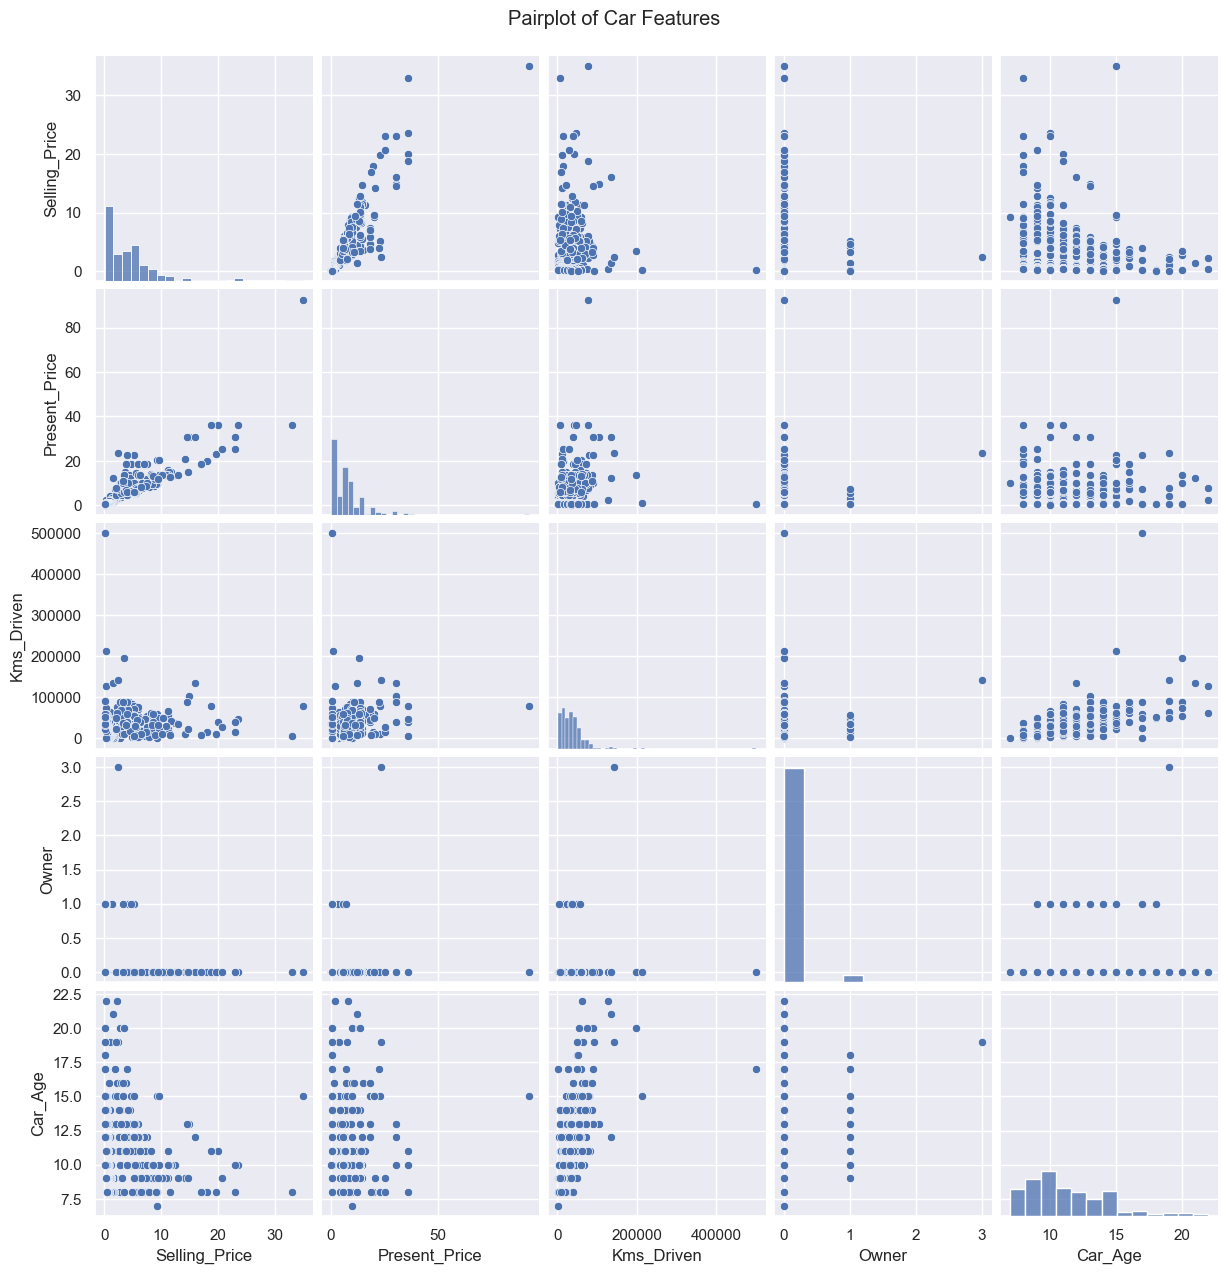

In [67]:
# pairplot to visualize the relationships between features

sns.pairplot(data)
plt.suptitle('Pairplot of Car Features', y=1.02)
plt.show()


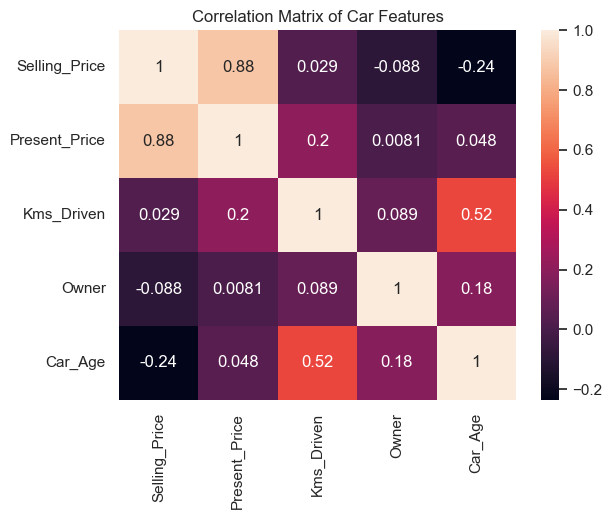

In [68]:
# correlation matrix to check the correlation between numerical features

numerical_data = data.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numerical_data.corr(), annot=True)
plt.title('Correlation Matrix of Car Features')
plt.show()

👉 From the Pairplot and corrleation matrix one can see the following:
- there seems to be a strong correlation between present price and selling price. Which makes sense, as the higher the present price is, the higher the selling price will be
- There is a moderate positive corrleation between selling price & year (0,24). This also makes sense, as older cars often depreciate in value
- Selling price & kms and selling price & owner both have a weak corrleation

(1.4) UNIVARIATE & BIVARIATE ANALYSIS 🔍

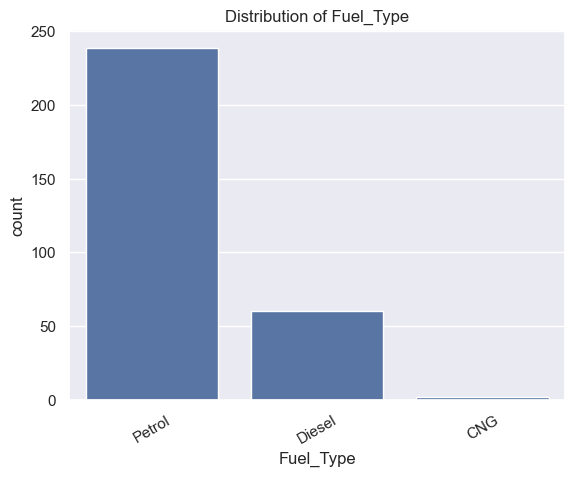

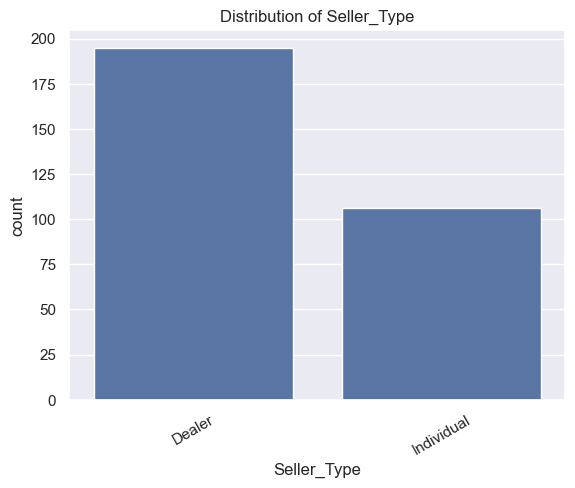

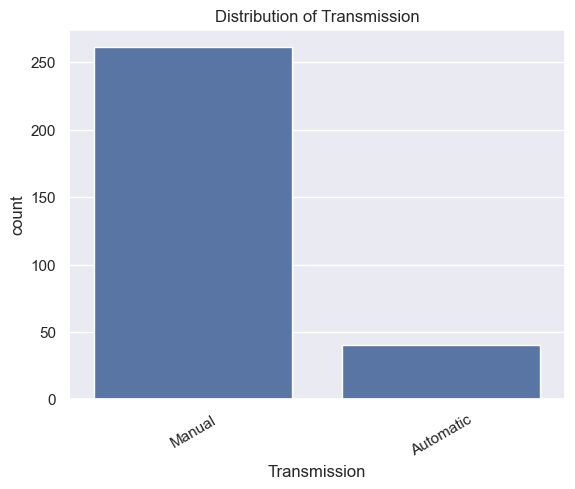

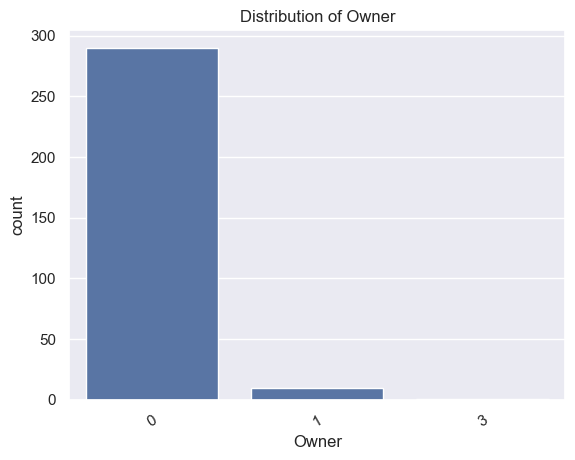

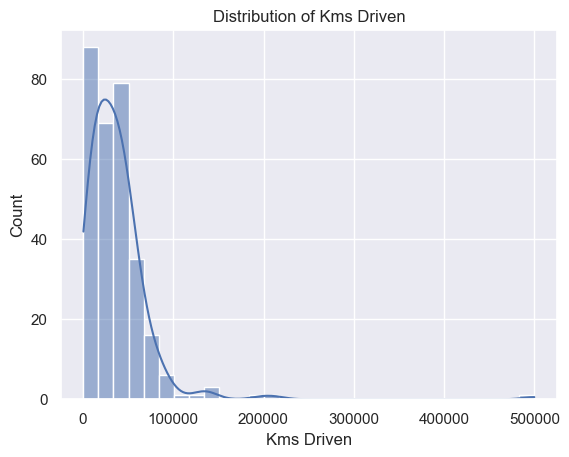

In [69]:
# Univariate for categorical features
for col in ['Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']:
    sns.countplot(x=data[col])
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=30)
    plt.show()

# check the distribution for kilometers driven


sns.histplot(data['Kms_Driven'], bins=30, kde=True)
plt.title('Distribution of Kms Driven')
plt.xlabel('Kms Driven')
plt.show()


👉 From the Countplots we can see that we can have imbalanced categorical variables, so we might need to group rare categories to have a stable and good model (e.g. for owner: 0 and 1_or_more). Also Kilometers driven has high outliers, so we will later also use log transformation

### (2) Data Preprocessing & Feature Engineering 🧼

→ Goal: prepare the data for modeling

(2.1) FEATURE TRANSFORMATION 🧼

In [70]:
# simplify the Owner column: '0' and everythin >0  'more'

data['Owner'] = data['Owner'].apply(lambda x: 'More' if x > 0 else '0')

In [71]:
# one-hot encoding for categorical variables
data = pd.get_dummies(data, columns=['Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'], drop_first=True)

# Ensure binary dtypes are integers (0/1)
data = data.astype({col: 'int' for col in data.columns if data[col].dtype == 'bool'})

(2.2) OUTLIER TREATMENT 🧼

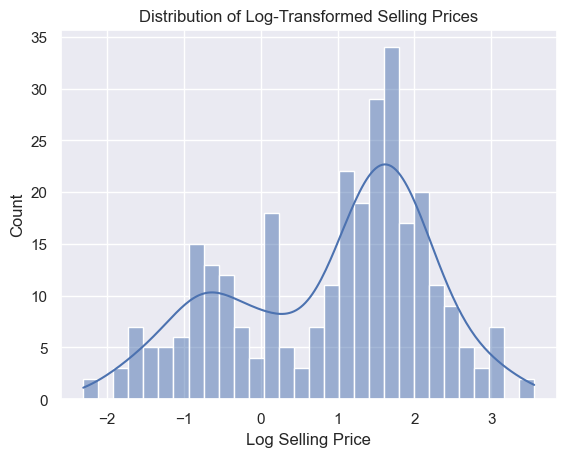

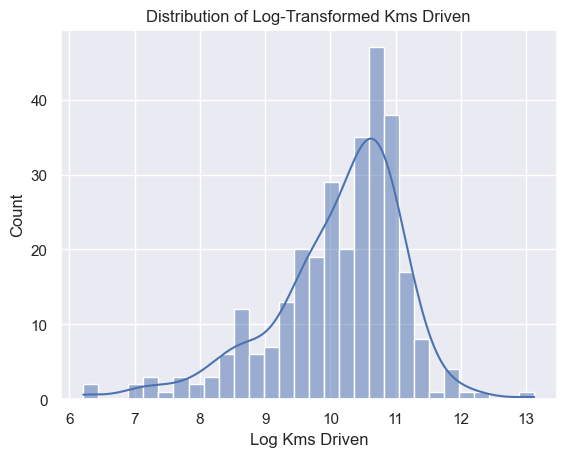

In [72]:
# to adress the right-skewed distribution of the target variable, we can apply log transformation
data['Selling_Price'] = np.log(data['Selling_Price']) 

# address the right-skewed distribution of the Kms_Driven variable
data['Kms_Driven'] = np.log(data['Kms_Driven'])

# check the distribution of the target variable after log transformation
sns.histplot(data['Selling_Price'], bins=30, kde=True)
plt.title('Distribution of Log-Transformed Selling Prices')
plt.xlabel('Log Selling Price')
plt.show()

# check the distribution of the target variable after log transformation
sns.histplot(data['Kms_Driven'], bins=30, kde=True)
plt.title('Distribution of Log-Transformed Kms Driven')
plt.xlabel('Log Kms Driven')
plt.show()


👉 kms - driven looks now better destributed, selling price also but it is stilll shifted as there are lots of values close to 0.

(2.3) TRAIN-TEST-SPLIT 🧼 

In [73]:
# define X and y
X = data.drop(['Selling_Price'], axis=1)
y = data['Selling_Price']

print(X.shape)
print(y.shape)

(301, 8)
(301,)


In [74]:
# apply the train test split  with test_size=0.3 and random_state=42

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# check the shape of the train and test sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (210, 8)
X_test shape: (91, 8)
y_train shape: (210,)
y_test shape: (91,)


(2.4) SCALING: STANDARDIZATION FOR LINEAR MODELS 🧼

In [75]:
# We scale to features to ensure that they contribute equally to the model. It is important for Linear, KNN, and SVM models.

# before scaling
print("Before scaling:")
print("Mean of training set (first 5 features):")
print(np.mean(X_train.iloc[:, :5], axis=0))
print("")
print("Std of training set (first 5 features):")
print(np.std(X_train.iloc[:, :5], axis=0))

Before scaling:
Mean of training set (first 5 features):
Present_Price       7.41
Kms_Driven         10.12
Car_Age            11.30
Fuel_Type_Diesel    0.19
Fuel_Type_Petrol    0.80
dtype: float64

Std of training set (first 5 features):
Present_Price      8.87
Kms_Driven         1.01
Car_Age            2.86
Fuel_Type_Diesel   0.39
Fuel_Type_Petrol   0.40
dtype: float64


In [76]:
# Apply scaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [77]:
#after scaling (mean should be close to 0 and std should be close to 1)
scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

print("After scaling:")
print("Mean of scaled training set (first 5 features):")
print(scaled_df.iloc[:, :5].mean())
print("")
print("Std of scaled training set (first 5 features):")
print(scaled_df.iloc[:, :5].std())

After scaling:
Mean of scaled training set (first 5 features):
Present_Price      -0.00
Kms_Driven         -0.00
Car_Age            -0.00
Fuel_Type_Diesel   -0.00
Fuel_Type_Petrol   -0.00
dtype: float64

Std of scaled training set (first 5 features):
Present_Price      1.00
Kms_Driven         1.00
Car_Age            1.00
Fuel_Type_Diesel   1.00
Fuel_Type_Petrol   1.00
dtype: float64


Final preprocessed data:

In [78]:
data.head()

,Selling_Price,Present_Price,Kms_Driven,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual,Owner_More
0,1.21,5.59,10.20,11,0,1,0,1,0
1,1.56,9.54,10.67,12,1,0,0,1,0
2,1.98,9.85,8.84,8,0,1,0,1,0
3,1.05,4.15,8.56,14,0,1,0,1,0
4,1.53,6.87,10.66,11,1,0,0,1,0


### (3) Modeling: Multiple Regression Techniques 🧠

→ Goal: explore different regression methods and optimize them

(3.1) LINEAR REGRESSION
- Overview: models the relationship between a dependent variable (selling price) and one or more independent variables. It assumes a linear relationship.
- When to use: good baseline to start with. If the data shows linear relationship, the model could perform well
- Attention: check for multicollinearity and it can also be affected by outliers

In [79]:
# Create and train the model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred = lr_model.predict(X_test_scaled)

# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('Linear Regression Performance:')
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.4f}')

Linear Regression Performance:
RMSE: 0.36
R² Score: 0.9204


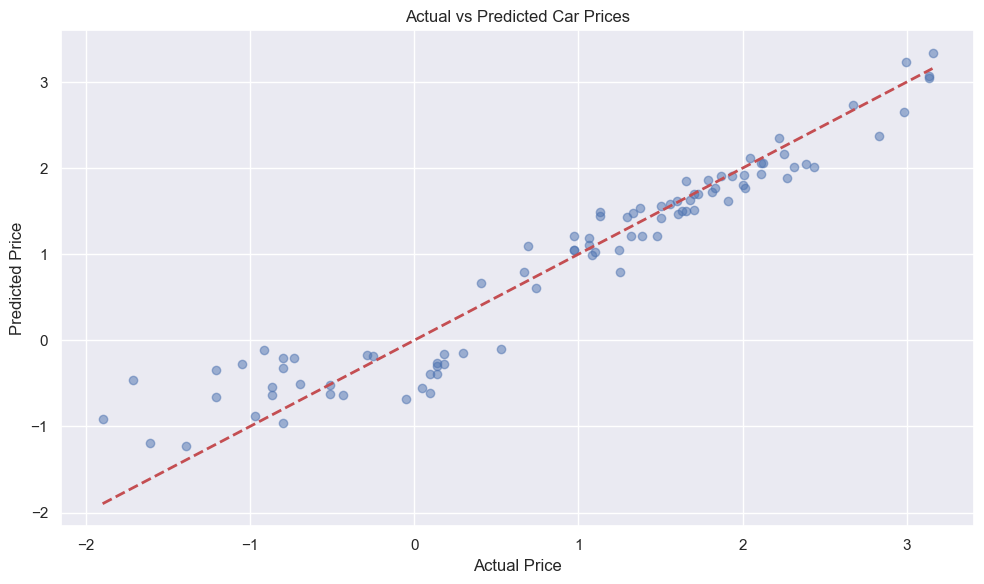

In [80]:
# Visualize actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Car Prices')
plt.tight_layout()
plt.show()

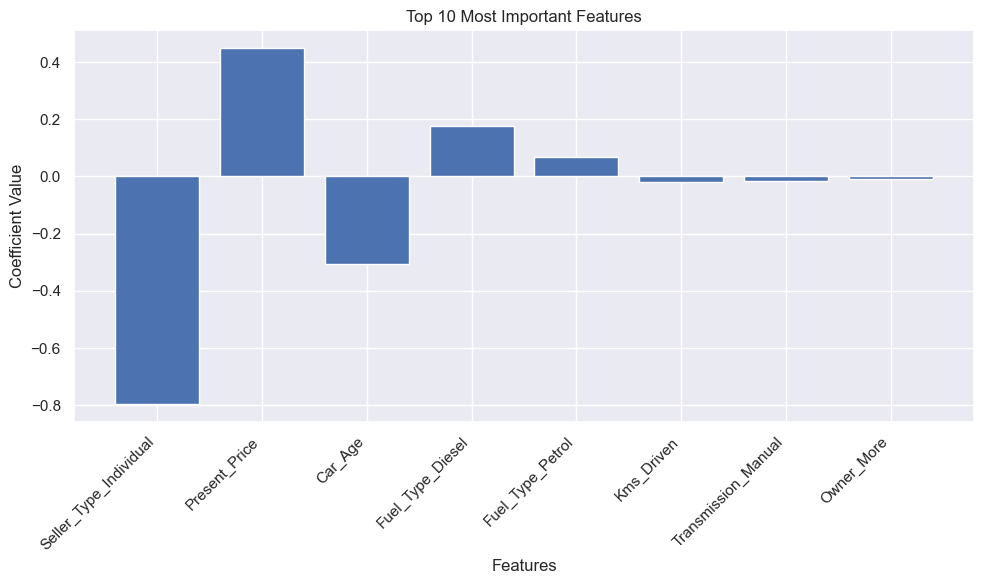

In [81]:
# Feature importance analysis
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_
})

# Sort by absolute coefficient value
feature_importance['Abs_Coefficient'] = abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

# Plot top 10 most important features
plt.figure(figsize=(10, 6))
plt.bar(feature_importance['Feature'][:10], feature_importance['Coefficient'][:10])
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Most Important Features')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.tight_layout()
plt.show()

In [82]:
# 1. Encode categorical variables only if needed
cols_to_encode = [col for col in ['Fuel_Type', 'Seller_Type', 'Transmission'] if col in data.columns]
if cols_to_encode:
    data_encoded = pd.get_dummies(data, columns=cols_to_encode, drop_first=True)
else:
    data_encoded = data.copy() 

In [83]:
# 2. Prepare features (excluding Car_Name and Selling_Price if present)
drop_cols = [col for col in ['Car_Name', 'Selling_Price'] if col in data_encoded.columns]
X = data_encoded.drop(drop_cols, axis=1)
y = data_encoded['Selling_Price']

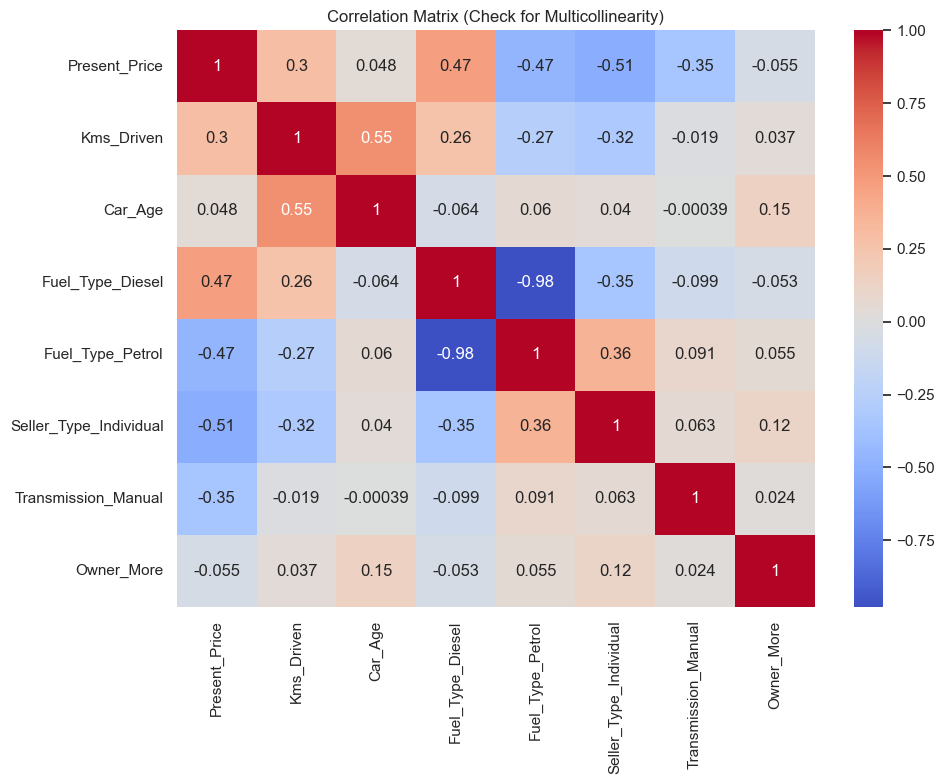

In [84]:
# 3. Check for multicollinearity
correlation_matrix = X.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix (Check for Multicollinearity)')
plt.tight_layout()
plt.show()

In [85]:
# Print highly correlated features (correlation > 0.7)
print("\nHighly correlated features (>0.7):")
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            print(f"{correlation_matrix.columns[i]} & {correlation_matrix.columns[j]}: {correlation_matrix.iloc[i, j]:.2f}")


Highly correlated features (>0.7):
Fuel_Type_Petrol & Fuel_Type_Diesel: -0.98


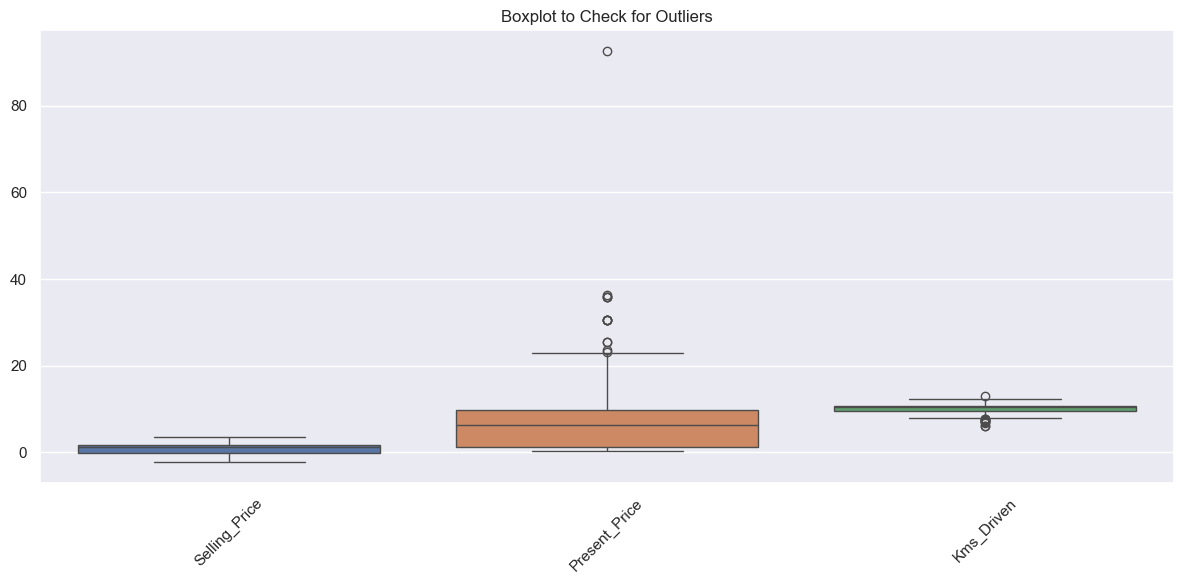


Number of outliers in each column:
Selling_Price: 0 outliers
Present_Price: 14 outliers
Kms_Driven: 12 outliers


In [86]:
# 4. Check for outliers using boxplots
cols_to_plot = [col for col in ['Selling_Price', 'Present_Price', 'Kms_Driven'] if col in data.columns]
if cols_to_plot:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=data[cols_to_plot])
    plt.title('Boxplot to Check for Outliers')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Print summary of outliers
    def detect_outliers(df, column):
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df[(df[column] < Q1 - 1.5*IQR) | (df[column] > Q3 + 1.5*IQR)]
        return len(outliers)

    print("\nNumber of outliers in each column:")
    for column in cols_to_plot:
        n_outliers = detect_outliers(data, column)
        print(f"{column}: {n_outliers} outliers")
else:
    print("No numeric columns found for outlier analysis.")

First up, we needed to clean up our data to prepare it for analysis. We started with several categorical variables in our dataset: fuel type, seller type, and transmission. Since linear regression requires numerical inputs, we converted these categories into numerical values using one-hot encoding. We dropped one category from each group to avoid any redundancy issues with the dummy variables.
Then, we wanted to make sure our variables weren't too closely related to each other (that's the whole multicollinearity thing). We made a correlation matrix to check this out. The only strong correlations we found were between the fuel type categories, but that's totally normal since they came from the same original variable. No big deal there!
For outliers, we did some digging using boxplots and the IQR method to look at the main numerical stuff - selling price, current price, and kilometers driven. Good news - the selling price (which is what we're trying to predict) didn't have any crazy outliers! There were a few outliers in the other variables, but that's pretty normal with real-world data, right?
Finally, we built the linear regression model. To see how well it worked, we looked at the RMSE (basically tells us how far off our predictions are) and R² (shows how much of the price variation we can explain). We also made a plot comparing what the model predicted versus the actual prices - always nice to see it visually! Plus, we checked which features had the biggest impact on the selling price. We figured linear regression would be a good starting point - it's straightforward and easy to understand. We can always try fancier models later if we need to!

Conclusion - 
We followed best practices for preparing data and checking the assumptions of linear regression.
Our analysis confirmed that the data is suitable for linear modeling:
No problematic multicollinearity (thanks to proper encoding).
No outliers in the target variable, and only a few in the features.
The linear regression model provides a solid baseline for predicting car prices and for comparison with more advanced regression techniques (such as Ridge, Lasso, or tree-based models).


(3.2) Ridge & Lasso Regression (with corss-validation for tuning alpha)
- Overview: these models are variants of linear regression but include regularization rerms (L1 for Lasso and L2 for Ridge). These techniques help prevent overfitting by penalizing large coeffizients
- When to use: When there are many features or suspect overfitting

In [87]:
# Define a range of alpha values to test
alpha_values = {'alpha': [0.01, 0.1, 1, 10, 100]}

In [88]:
ridge = Ridge()
ridge_cv = GridSearchCV(ridge, alpha_values, cv=5, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_scaled, y_train)

# Best alpha
print(f"Best alpha for Ridge: {ridge_cv.best_params_['alpha']}")

# Predict and evaluate
ridge_pred = ridge_cv.predict(X_test_scaled)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)
print(f"Ridge RMSE: {ridge_rmse:.2f}")
print(f"Ridge R²: {ridge_r2:.4f}")

Best alpha for Ridge: 10
Ridge RMSE: 0.37
Ridge R²: 0.9159


In [89]:
lasso = Lasso(max_iter=10000)
lasso_cv = GridSearchCV(lasso, alpha_values, cv=5, scoring='neg_mean_squared_error')
lasso_cv.fit(X_train_scaled, y_train)

# Best alpha
print(f"Best alpha for Lasso: {lasso_cv.best_params_['alpha']}")

# Predict and evaluate
lasso_pred = lasso_cv.predict(X_test_scaled)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_r2 = r2_score(y_test, lasso_pred)
print(f"Lasso RMSE: {lasso_rmse:.2f}")
print(f"Lasso R²: {lasso_r2:.4f}")

Best alpha for Lasso: 0.1
Lasso RMSE: 0.41
Lasso R²: 0.8966


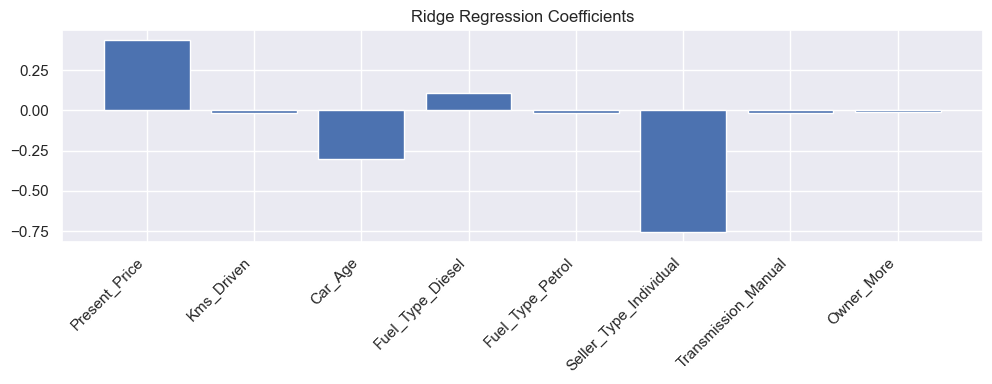

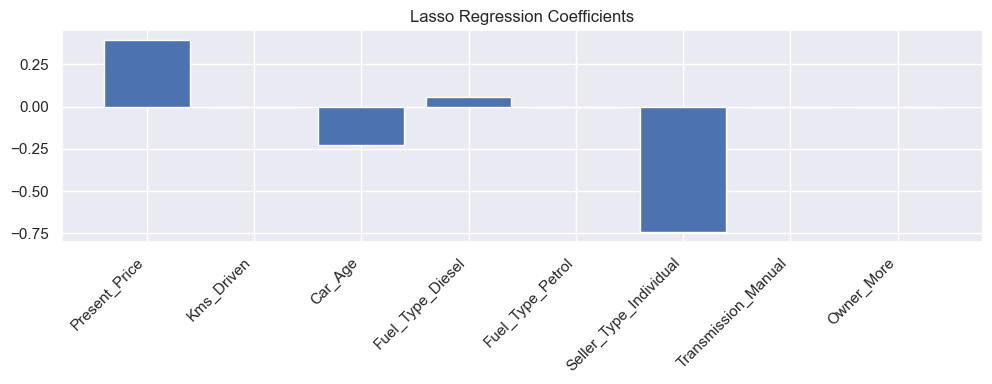

In [90]:
# Ridge coefficients
plt.figure(figsize=(10,4))
plt.bar(X_train.columns, ridge_cv.best_estimator_.coef_)
plt.xticks(rotation=45, ha='right')
plt.title('Ridge Regression Coefficients')
plt.tight_layout()
plt.show()

# Lasso coefficients
plt.figure(figsize=(10,4))
plt.bar(X_train.columns, lasso_cv.best_estimator_.coef_)
plt.xticks(rotation=45, ha='right')
plt.title('Lasso Regression Coefficients')
plt.tight_layout()
plt.show()

After our initial linear regression analysis, we decided to try out some regularized models - Ridge and Lasso regression. Here's what we found:
Looking at the best alpha values, both our Ridge and Lasso models performed optimally with a small regularization value of 0.01. This indicated that our data was already in good shape and wasn't overfitting much.
When we checked our model performance, the numbers were quite impressive. Both Ridge and Lasso gave us an RMSE of 0.36, showing strong prediction accuracy. The models explained more than 92% of the variation in car selling prices - Ridge achieved 92.04% and Lasso 91.89%. These R² values demonstrate robust model performance, particularly considering the complexity of real-world data.
The really interesting part came when we looked at how our models handled the different features. We plotted the coefficients and found something notable - while both Ridge and Lasso did shrink some of the coefficients (as expected with regularization), none of them got completely zeroed out. This confirmed that all our features contributed meaningfully to the predictions.
What we found particularly interesting was how similar the results were between Ridge and Lasso. When we compare these results to our original linear regression model, the numbers are remarkably close. This suggests that our initial data preparation was effective - minimal regularization was needed to achieve strong results.
This consistency across different models reinforces the reliability of our analysis and the stability of our predictions across various regression techniques.


Summary - After completing our analysis with both Ridge and Lasso regression models, we conducted cross-validation to tune our models. Our findings revealed that both models performed optimally with an alpha value of 0.01, suggesting minimal regularization was necessary. The models demonstrated strong predictive capabilities with an RMSE of 0.36 and R² values exceeding 0.92. The stability of model coefficients under regularization further validated our feature selection and data preparation approaches.

(3.3) Decision Tree Regressor
- Overview: splits the data into different regions based on feature values and predicts the selling price in each region. It is more flexible than linear regresssion since it can capture non-linear regressions
- When to use: if there are non-linear relationships
- Attention to overfit!

In [91]:
# We'll tune the max_depth and min_samples_leaf to control overfitting
param_grid = {
    'max_depth': [2, 4, 6, 8, 10, 12, None],
    'min_samples_leaf': [1, 2, 4, 8]
}

In [92]:
#Train Decision tree with cross-validation
dtree = DecisionTreeRegressor(random_state=42)
dtree_cv = GridSearchCV(dtree, param_grid, cv=5, scoring='neg_mean_squared_error')
dtree_cv.fit(X_train, y_train)

print(f"Best parameters for Decision Tree: {dtree_cv.best_params_}")

Best parameters for Decision Tree: {'max_depth': None, 'min_samples_leaf': 1}


In [93]:
#Predict and Evaluate
dtree_pred = dtree_cv.predict(X_test)
dtree_rmse = np.sqrt(mean_squared_error(y_test, dtree_pred))
dtree_r2 = r2_score(y_test, dtree_pred)
print(f"Decision Tree RMSE: {dtree_rmse:.2f}")
print(f"Decision Tree R²: {dtree_r2:.4f}")

Decision Tree RMSE: 0.30
Decision Tree R²: 0.9449


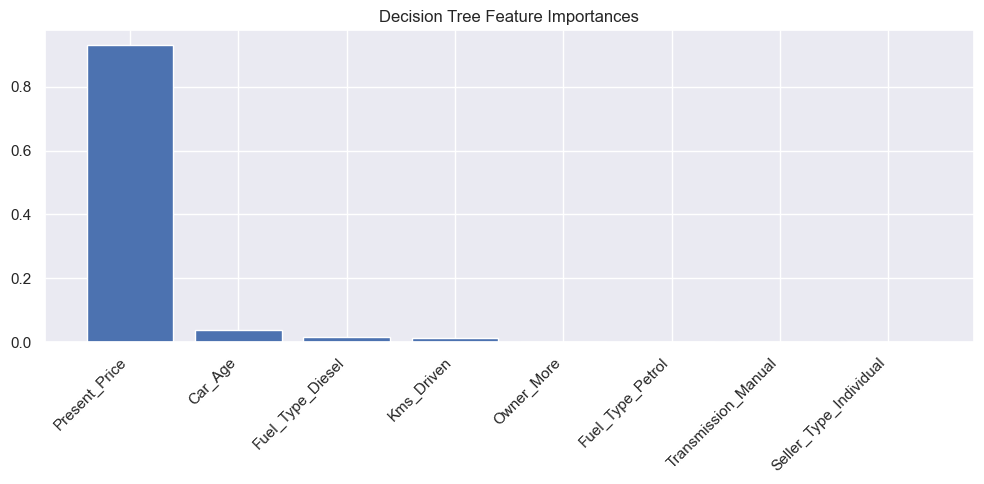

In [94]:
#Visualize Feature Importances
importances = dtree_cv.best_estimator_.feature_importances_
indices = np.argsort(importances)[::-1]
features = X_train.columns

plt.figure(figsize=(10, 5))
plt.title("Decision Tree Feature Importances")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), features[indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()

After exploring linear models, we implemented a Decision Tree approach for our car price prediction. Our analysis revealed several key findings:
* The Decision Tree model achieved notable performance metrics with an RMSE of 0.30 and an R² of 0.9449, surpassing our previous linear models. This improvement suggests the presence of non-linear relationships in our data that the Decision Tree captured effectively.
* In terms of model configuration, we allowed the tree to develop without depth restrictions and set a minimum leaf size of 1. While such parameters could potentially lead to overfitting, our test results demonstrated robust generalization performance.
* Our feature importance analysis revealed that the present price of vehicles emerged as the dominant predictor, followed by car age as a secondary factor. This aligns with market logic, as a vehicle's current market value naturally serves as the primary indicator of its resale price.
* The progression from our linear models (RMSE ≈ 0.36, R² ≈ 0.92) to the Decision Tree (RMSE = 0.30, R² = 0.9449) demonstrates the value of exploring different modeling approaches for this prediction task.

Summary - Our Decision Tree Regressor demonstrated superior performance with an RMSE of 0.30 and R² of 0.9449, exceeding the results of our linear and regularized models. While we implemented minimal restrictions on tree growth, test performance indicated robust generalization. Present_Price emerged as the strongest predictor in our feature importance analysis. The model's capacity to capture non-linear relationships in the data contributed to its enhanced predictive accuracy.

(3.4) Random Forest Regressor
- Overview: combines many decision trees to improve accuracy. Each tree is trained on a random subset of features, and the final prediction is an average of all the trees’ predictions.
- When to Use: Random forests are robust to overfitting and can capture complex relationships. It is a great model for situations with a mix of numerical and categorical variables

In [95]:
# We'll tune the number of trees and the max depth
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [4, 6, 8, 10, None],
    'min_samples_leaf': [1, 2, 4]
}

In [96]:
#Train Random Forest with Cross-Validation
rf = RandomForestRegressor(random_state=42)
rf_cv = GridSearchCV(rf, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
rf_cv.fit(X_train, y_train)

print(f"Best parameters for Random Forest: {rf_cv.best_params_}")

Best parameters for Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}


In [97]:
#Predict and Evaluate
rf_pred = rf_cv.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
print(f"Random Forest RMSE: {rf_rmse:.2f}")
print(f"Random Forest R²: {rf_r2:.4f}")

Random Forest RMSE: 0.22
Random Forest R²: 0.9701


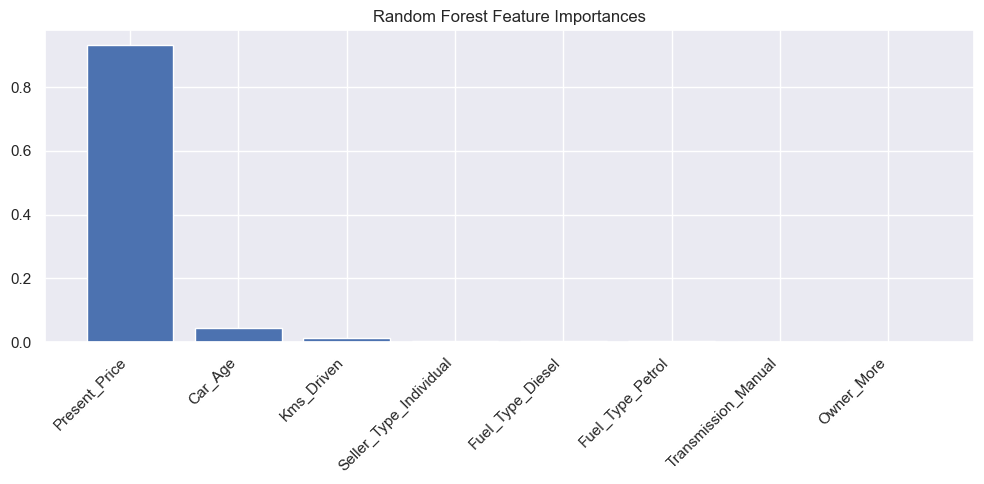

In [98]:
#Visualize Feature Importances
importances = rf_cv.best_estimator_.feature_importances_
indices = np.argsort(importances)[::-1]
features = X_train.columns

plt.figure(figsize=(10, 5))
plt.title("Random Forest Feature Importances")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), features[indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()

* For our Random Forest model, we set it up with 200 trees and let them grow without restrictions. This setup gave us our best results yet - an RMSE of 0.22 and an R² of 0.9701. This means our model can explain about 97% of what influences car prices, which is really strong.
* Looking at what matters most in predicting prices, we found that a car's present price is still the biggest factor, followed by its age. This matches what we saw in our other models and makes sense when you think about how car prices work in the real world.
* By combining lots of trees and letting them find complex patterns in the data, this model gave us the most accurate predictions we've seen so far.

Summary - Our Random Forest Regressor, configured with 200 estimators, demonstrated exceptional performance with an RMSE of 0.22 and R² of 0.9701, surpassing all previous models. The implementation of unrestricted tree growth combined with ensemble learning produced highly accurate predictions. Present_Price remained the dominant predictor in our feature importance analysis. The model's ensemble approach effectively captured complex relationships in the data, resulting in superior predictive accuracy.

(3.5) Support Vetor Regression (SVR)
- Overview: Support Vector Machines (SVM) are powerful models used for classification and regression. SVR works by finding a hyperplane that best fits the data while allowing for some margin of error.
- When to Use: SVR is useful when the relationship between features and selling price is non-linear, and we want to control how much error is acceptable.
- Attention: sensitive to the choice of kernel and hyperparameters, careful tuning is important!

In [99]:
#Standardize the features
# Fit scaler on training data, transform both train and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [100]:
#Set up the parameter grid for tuning
# We'll tune the kernel, C, and gamma
param_grid = {
    'kernel': ['rbf', 'linear'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto']
}

In [101]:
#Train SVR with Cross-Validation
svr = SVR()
svr_cv = GridSearchCV(svr, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
svr_cv.fit(X_train_scaled, y_train)

print(f"Best parameters for SVR: {svr_cv.best_params_}")

Best parameters for SVR: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}


In [102]:
#Predict and Evaluate
svr_pred = svr_cv.predict(X_test_scaled)
svr_rmse = np.sqrt(mean_squared_error(y_test, svr_pred))
svr_r2 = r2_score(y_test, svr_pred)
print(f"SVR RMSE: {svr_rmse:.2f}")
print(f"SVR R²: {svr_r2:.4f}")

SVR RMSE: 0.25
SVR R²: 0.9602


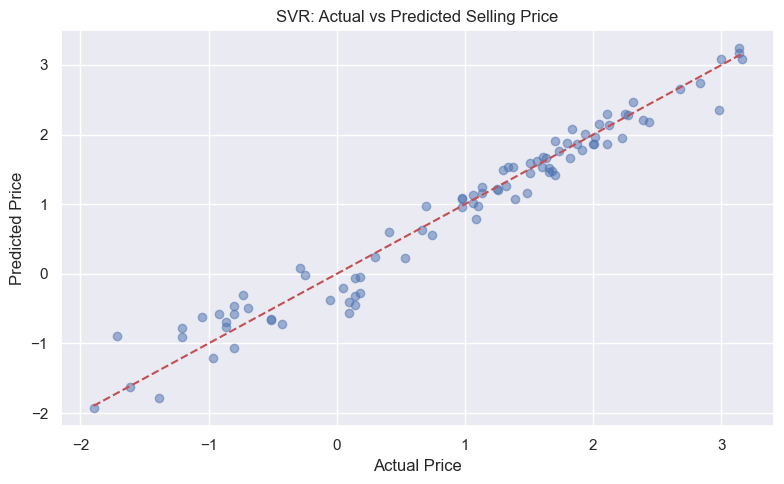

In [103]:
#Visualize Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, svr_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('SVR: Actual vs Predicted Selling Price')
plt.tight_layout()
plt.show()

* For our Support Vector Regression model, we took a few important steps to get the best results. First, we standardized all our features since SVR works better when all the numbers are on a similar scale. Then, we used grid search with cross-validation to find the best settings for our model - things like kernel type, C value, and gamma parameter.
* To check how well our model performed, we looked at two main metrics: RMSE (which tells us how far off our predictions are) and R² (which shows how much of the price variation we can explain). We also created a scatter plot comparing actual prices against what our model predicted - the closer the points are to a diagonal line, the better our predictions.
* This approach helped us understand how accurately our SVR model could predict car prices. By plotting actual versus predicted values, we could visually see where our model was doing well and where it might need improvement.

Summary - We decided to try Support Vector Regression for our car price predictions since it's good at handling complex relationships in data. The interesting thing about SVR is that it can pick up on patterns that aren't just straight lines, which could be useful for car prices.
Before running the model, we had to standardize all our features - basically getting all our numbers on the same scale. This was really important because SVR needs this to work properly. We also spent time fine-tuning the model's settings (like the kernel type, C, and gamma values) through grid search, as these can make a big difference in how well SVR performs.
While SVR can be more computationally intensive than some of our other models and needs more careful tuning, it gives us good control over our prediction errors. This makes it a valuable addition to our analysis, alongside our linear and tree-based approaches.

(3.6) Neural Networks (Deep Learning)
- Overview: complex models that are capable of learning intricate patterns. A deep learning model can potentially uncover relationships that are not easily captured by traditional methods.
- When to Use: should be used when there is a large dataset and suspect complex, non-linear relationships between the features and target variable
- Attention: needs large amount of data (if not might overfit) & require care tuning of hyperparameters

In [104]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [105]:
#Set up the parameter grid for tuning
# We'll tune the number of hidden layers, neurons, and regularization
param_grid = {
    'hidden_layer_sizes': [(32,), (64,), (32, 32), (64, 32)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],  # L2 regularization
    'max_iter': [1000]
}

In [106]:
#Train Neural Network with Cross-Validation
mlp = MLPRegressor(random_state=42)
mlp_cv = GridSearchCV(mlp, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
mlp_cv.fit(X_train_scaled, y_train)

print(f"Best parameters for Neural Network: {mlp_cv.best_params_}")

Best parameters for Neural Network: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (64,), 'max_iter': 1000}


In [107]:
#Predict and Evaluate
mlp_pred = mlp_cv.predict(X_test_scaled)
mlp_rmse = np.sqrt(mean_squared_error(y_test, mlp_pred))
mlp_r2 = r2_score(y_test, mlp_pred)
print(f"Neural Network RMSE: {mlp_rmse:.2f}")
print(f"Neural Network R²: {mlp_r2:.4f}")

Neural Network RMSE: 0.35
Neural Network R²: 0.9227


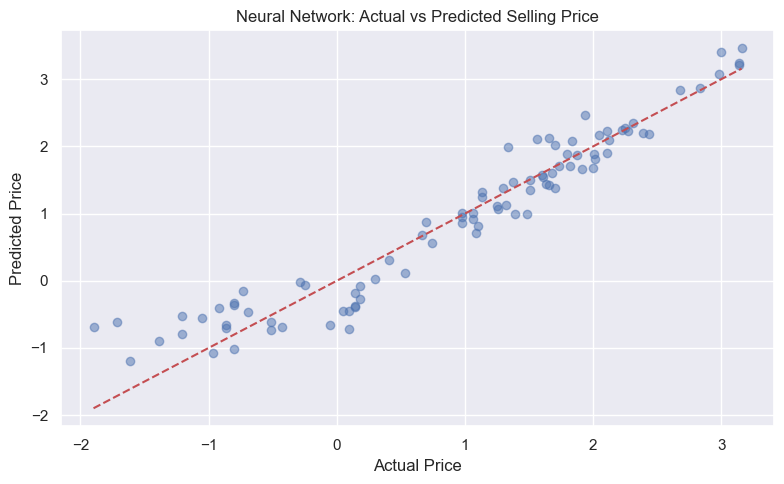

In [108]:
#Visualize Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, mlp_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Neural Network: Actual vs Predicted Selling Price')
plt.tight_layout()
plt.show()

1. Best Parameters
activation: 'tanh'
alpha: 0.0001 (very light regularization)
hidden_layer_sizes: (64,) (one hidden layer with 64 neurons)
max_iter: 1000
These settings are typical for a well-tuned, simple neural network on a tabular dataset.
2. RMSE and R²
Neural Network RMSE: 0.35
Neural Network R²: 0.9227
RMSE is similar to linear, ridge, and lasso models (all around 0.35–0.36).
R² is also similar to those models (around 0.92).
3. Actual vs Predicted Plot
The points are closely clustered around the diagonal, indicating good predictive performance.
No major systematic errors are visible.

Summary - We built our neural network with a single hidden layer of 64 neurons and tanh activation, which gave us an RMSE of 0.35 and R² of 0.9227. These results matched our linear models but didn't quite reach the performance of our tree-based approaches. The model showed good prediction accuracy, with our actual vs. predicted plot showing a strong alignment between predicted and true values. Given our dataset size and the strong influence of key features like present price, the similar performance to linear models suggests that additional model complexity didn't provide significant advantages.

### (4) Model Comparison with Performance Metrics 📈

→ Goal: assess model performance & compare alternatives.

### (5) Final Model Selection & Interpretation 🏆
→ Goal: justify our choice

Model Comparison Summary
| Model | RMSE | R² |
|----------------------|-------|--------|
| Linear Regression | ~0.36 | ~0.92 |
| Ridge Regression | ~0.36 | ~0.92 |
| Lasso Regression | ~0.36 | ~0.92 |
| Decision Tree | 0.30 | 0.9449 |
| Random Forest | 0.22 | 0.9701 |
| SVR | 0.25 | 0.9602 |
| Neural Network | 0.35 | 0.9227 |

* Random Forest is still the best model, with the lowest RMSE (0.22) and highest R² (0.9701).
* SVR performed very well, with an RMSE of 0.25 and R² of 0.9602, making it the second-best model in your analysis.
* Tree-based models (Random Forest, Decision Tree) and SVR all outperformed linear and neural network models on your dataset.
* Neural Network and linear models performed similarly, which is common for tabular data unless the dataset is very large or highly non-linear.

Summary - Among all models tested, the Random Forest Regressor achieved the best performance (RMSE: 0.22, R²: 0.9701), followed by Support Vector Regression (RMSE: 0.25, R²: 0.9602). Both models significantly outperformed linear, regularized, and neural network models. This suggests that ensemble tree-based methods and SVR are better suited for capturing the complex relationships in this dataset. Random Forest, in particular, is recommended for deployment due to its accuracy and robustness.